# Performance Measures for Classification Tasks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, OrdinalEncoder
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

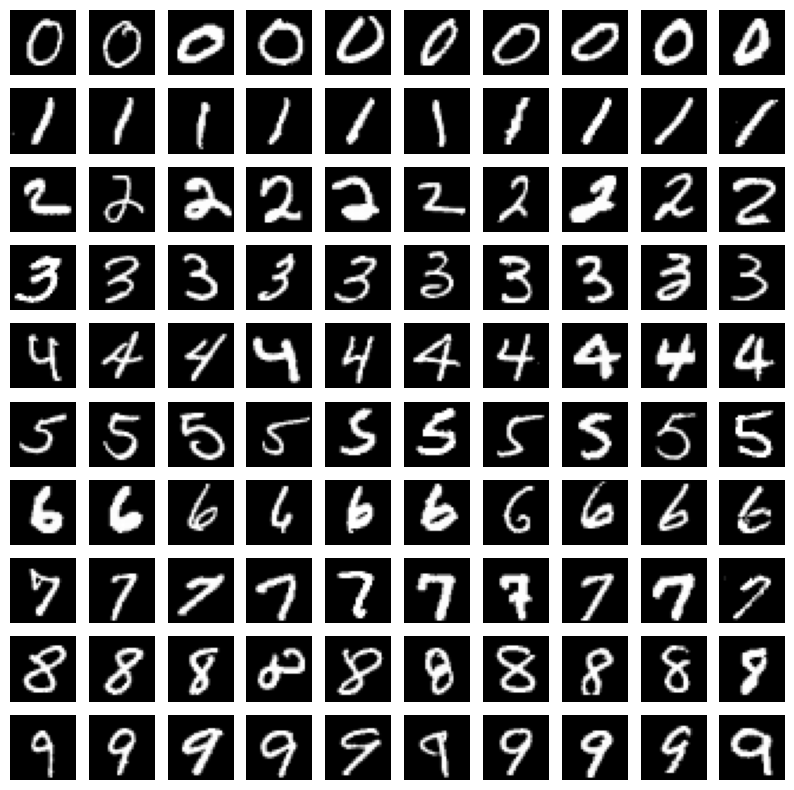

In [2]:
# Dataset

from sklearn.datasets import fetch_openml 
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X, t = mnist.data, mnist.target
t = t.astype(np.uint8)

# Training/Test Set
X_train, X_test, t_train, t_test = X[:60000], X[60000:], t[:60000], t[60000:]

grid=1
plt.figure(figsize=(10,10))
for i in range(10):
    loc = np.where(t_train==i)[0]
    idx = np.random.permutation(range(len(loc)))
    for j in range(10):
        plt.subplot(10,10,grid)
        plt.imshow(X_train[loc[idx[j]],:].reshape(28,28), cmap='gray')
        plt.axis('off')
        grid+=1

In [3]:
# Binary classification (digit 8 vs not-8)

t_train_8 = 1*(t_train==8)
t_test_8 = 1*(t_test==8)

In [4]:
model = Pipeline([('scaler', MinMaxScaler()),
                  ('log_reg', LogisticRegression(penalty=None, max_iter=200))])

model.fit(X_train, t_train_8)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('log_reg', LogisticRegression(max_iter=200, penalty=None))])

---

# Performance Measures for Classification Tasks

A key step in machine learning algorithm development and testing is determining a good error and evaluation metric.

**Evaluation metrics** help us to estimate how well our model is trained and it is important to pick a metric that matches our overall goal for the system.

Some common evaluation metrics include precision, recall, receiver operating curves, and confusion matrices.

## Confusion Matrix

A confusion matrix summarizes the classification accuracy across several classes. It shows the ways in which the classification model is confused when it makes predictions, allowing visualization of the performance of our algorithm. 

Generally, each row represents the instances of a actual class while each column represents the instances in an predicted class.

All correct predictions are located in the diagonal of the table. So it is easy to visually inspect the table for prediction errors, as they will be represented by values outside the diagonal.

We are often looking to discriminate between observations with a specific binary outcome, for example, event or no event. In our example, we can assign the event (digit 8) as "positive" and no-event (not digit 8) as "negative".

The confusion matrix for this two-class classification problem is:

|actual/predict|    digit 8    |  not-digit-8  |
|--------------|--------------|--------------|
|    digit-8    |      100     |       0      |
|  non-digit-8  |       0      |      50      |

* **True positive (TP):** correctly predicting positive events
* **False positive (FP):** incorrectly calling positive to a negative event
* **True negative (TN):** correctly predicting negative events
* **False negative (FN):** incorrectly labeling negative to a positive event

*In this salmon/non-salmon classification problem, what are the TP, FP, TN, FN values?*

|actual/predict|   Positive   |   Negative   |
|--------------|--------------|--------------|
|   Positive   |      TP      |      FN      |
|   Negative   |      FP      |      TN      |

In [5]:
from sklearn.metrics import confusion_matrix

y_train = model.predict(X_train)

print('Confusion Matrix - Training Set:')
confusion_matrix(t_train_8, y_train)

Confusion Matrix - Training Set:


array([[53484,   665],
       [ 1614,  4237]])

In [6]:
y_test = model.predict(X_test)

print('Confusion Matrix - Test Set:')
confusion_matrix(t_test_8, y_test)

Confusion Matrix - Test Set:


array([[8886,  140],
       [ 248,  726]])

Examples of each type of assessment:

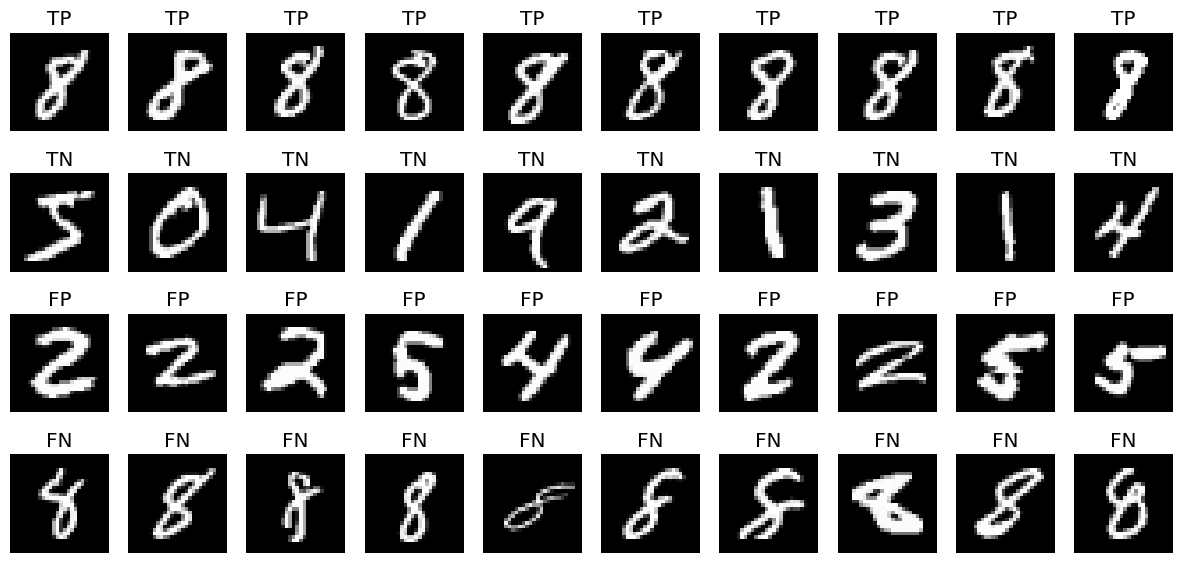

In [7]:
idx_tp = np.where((t_train_8==1)&(y_train==1))[0]

idx_tn = np.where((t_train_8==0)&(y_train==0))[0]

idx_fp = np.where((t_train_8==0)&(y_train==1))[0]

idx_fn = np.where((t_train_8==1)&(y_train==0))[0]

idx = np.vstack((idx_tp[:10], idx_tn[:10], idx_fp[:10], idx_fn[:10]))

plt.figure(figsize=(15,7))
labels=['TP','TN','FP','FN']
grid=1
for i in range(4):
    for j in range(10):
        plt.subplot(4,10,grid)
        plt.imshow(X_train[idx[i,j],:].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title(labels[i])
        grid+=1

---

# Precision, Recall & Fall-Out

* **Precision**, also called Positive Predictive Value (PPV), is the performance of detection

\begin{align*}
\text{Precision} = \text{PPV} = \frac{TP}{TP + FP}
\end{align*}

* **Recall**, also called True Positive Rate (TPR) or Sensitivity, is the probability of detection

\begin{align*}
\text{Recall} = \text{TPR} = \text{Sensitivity} = \frac{TP}{TP + FN}
\end{align*}

* **Fall-out**, also called False Positive Rate (FPR), is the probability of false alarm

\begin{align*}
\text{Fall-out} = \text{FPR} = \frac{FP}{FP + TN}
\end{align*}

* **Specificity**, also called True Negative Rate (TNR), is the probability of negative events detection

\begin{align*}
\text{Specificity} = \frac{TN}{TN + FP}
\end{align*}

* **F1-score**, also called F-score or F-measure, is a measure of a model's accuracy. It considers both the precision and the recall.

\begin{align*}
\text{F1-score} = 2\times\frac{\text{Precision}\times \text{Recall}}{\text{Precision} + \text{Recall}}
\end{align*}

* Learn about many other measures on this [Wikipedia page](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) and [Scikit-Learn's Classification Metrics Module](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics).

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [9]:
precision_score(t_train_8, y_train)

np.float64(0.8643410852713178)

In [10]:
recall_score(t_train_8, y_train)

np.float64(0.7241497179969236)

In [11]:
f1_score(t_train_8, y_train)

np.float64(0.7880591462847577)

The F1 score favors classifiers that have similar precision and recall. Unfortunately, you can't have it both ways: increasing precision reduces recall, and vice versa. This is called the **precision/recall trade-off**.

# Finding a New Threshold in Binary Classification

In this binary classifier, the decision surface is as follows:

\begin{cases}
1 & \mathbf{w}^T\mathbf{x}+w_0\geq 0\\
0 & \mathbf{w}^T\mathbf{x}+w_0<0
\end{cases}

The threshold $\delta=0$ can be changed to maximize some performance measure:

\begin{cases}
1 & y(\mathbf{x})=\phi(\mathbf{w}^T\mathbf{x}+w_0)\geq \delta\\
0 & y(\mathbf{x})=\phi(\mathbf{w}^T\mathbf{x}+w_0)<\delta
\end{cases}

array([4.13871708])

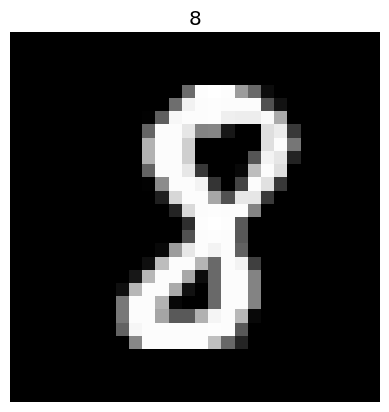

In [12]:
idx=24_000
plt.imshow(X_train[idx].reshape(28,28), cmap='gray')
plt.title(t_train[idx]); plt.axis('off');

y_scores = model.decision_function([X_train[idx]]) # computes the regression part, w^T@x+w0

y_scores

In [13]:
1/(1+np.exp(-y_scores))

array([0.98430691])

In [14]:
model.predict_proba([X_train[idx]]), model.predict([X_train[idx]]) 
# uses threshold of 0.5 by default

(array([[0.01569309, 0.98430691]]), array([1]))

In [15]:
threshold = 0 # for regression part, w^T@X+w0

y_some_digit_pred = y_scores>threshold
y_some_digit_pred

array([ True])

In [16]:
threshold = 8000

y_some_digit_pred = y_scores>threshold

y_some_digit_pred

array([False])

In [17]:
y_scores = model.decision_function(X_train)

y_scores

array([-10.69140914,  -8.28294243, -11.46589105, ...,  -3.75523349,
       -14.34637969,   0.14322034])

In [18]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(t_train_8, y_scores)

## Finding Threshold where Precision >= 90%

Threshold =  0.5017212266764774


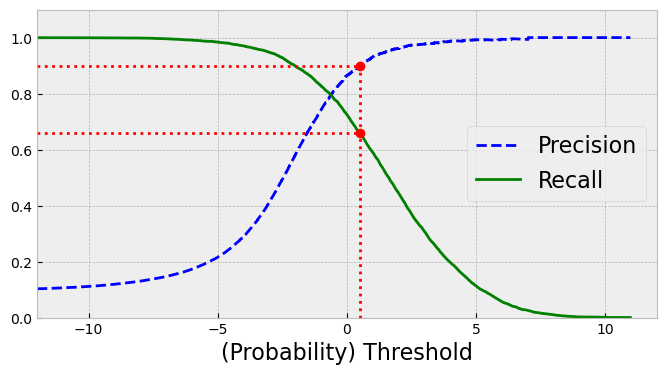

In [19]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
    plt.legend(loc='center right', fontsize=16)
    plt.xlabel('(Probability) Threshold', fontsize=16)
    plt.grid(True)
    plt.axis([-12, 12, 0, 1.1])

recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
print('Threshold = ', threshold_90_precision)

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], 'r:')
plt.plot([-12, threshold_90_precision], [0.9, 0.9], 'r:')
plt.plot([-12, threshold_90_precision], [recall_90_precision, recall_90_precision], 'r:')
plt.plot([threshold_90_precision], [0.9], 'ro')
plt.plot([threshold_90_precision], [recall_90_precision], 'ro');

Another way to select a good precision/recall trade-off is to plot precision directly against recall.

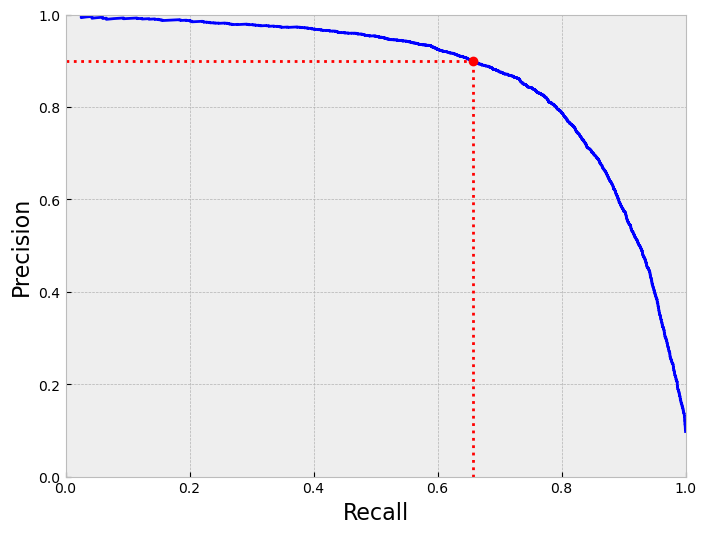

In [20]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, 'b-', linewidth=2)
    plt.xlabel('Recall', fontsize=16)
    plt.ylabel('Precision', fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], 'r:')
plt.plot([0.0, recall_90_precision], [0.9, 0.9], 'r:')
plt.plot([recall_90_precision], [0.9], 'ro');

In [21]:
y_train_pred_90 = 1*(y_scores>=threshold_90_precision)

In [22]:
precision_score(t_train_8, y_train_pred_90) 

np.float64(0.9000935891436593)

In [23]:
recall_score(t_train_8, y_train_pred_90)

np.float64(0.6574944453939497)

# ROC Curves

**Receiver Operating Characteristic (ROC) curve** is the plot between the true positive rate (TPR) and the false positive rate (FPR), where the TPR is defined as the y-axis and FPR is defined as the x-axis.

* ROC curves were first developed for RADAR systems, hence the name.

* Given a binary classifier and its threshold, the (x,y) coordinates of ROC space can be calculated from all the prediction result. You trace out a ROC curve by varying the threshold to get all of the points on the ROC.

* The diagonal between (0,0) and (1,1) separates the ROC space into two areas, which are left up area and right bottom area. The points above the diagonal represent good classification (better than random guess) which below the diagonal represent bad classification (worse than random guess).

* *What is the perfect prediction point in a ROC curve?*

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(t_train_8, y_scores)

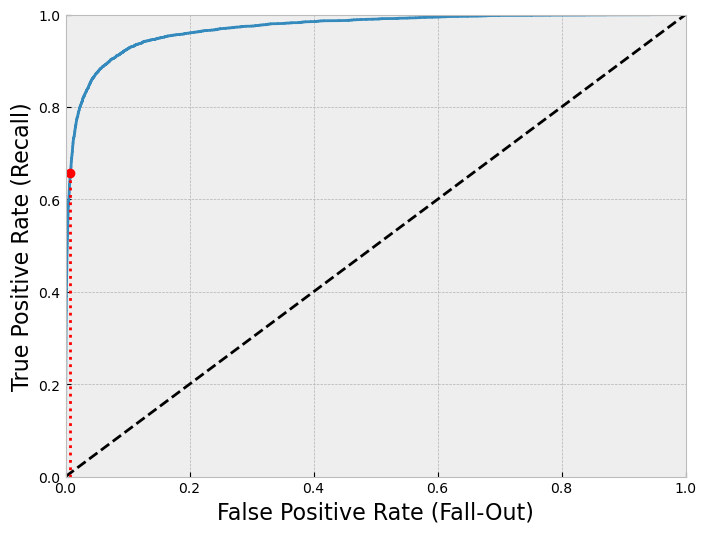

In [25]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], 'r:')
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], 'r:')
plt.plot([fpr_90], [recall_90_precision], 'ro');

## Area Under the Curve (AUC)

One way to compare classifiers is to measure the area under the curve (AUC). AUC is simply the area under the ROC curve. Random guessing can achieve the diagonal line, so the minimum AUC is 1/2. The maximum AUC is 1, which is achieved by a test that is always right; the ROC curve is along the left and top axes.

In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_score(t_train_8, y_scores)

np.float64(0.9701866829348704)

Since the ROC curve is so similar to the precision/recall (PR) curve, you may wonder how to decide which one to use. As a rule of thumb, you should prefer the PR curve whenever the positive class is rare or when you care more about the false positives than the false negatives. Otherwise, use the ROC curve. For example, looking at the previous ROC curve (and the ROC AUC score), you may think that the classifier is really good. But this is mostly because there are few positives (8s) compared to the negatives (non-8s). In contrast, the PR curve makes it clear that the classifier has room for improvement (the curve could be closer to the top-right corner).

---

## Softmax Regression

Once you have computed the score of every class for the instance $\mathbf{x}$, i.e. $y_k(\mathbf{x})$, you can estimate the probability $p_k$ that the instance belongs to class $k$ by running the scores through the **softmax function**.

\begin{align*}
p_k = \frac{\exp(y_k(\mathbf{x}))}{\sum_{j=1}^K \exp(y_j(\mathbf{x}))}
\end{align*}

The function computes the exponential of every score, then normalizes them (dividing by the sum of all the exponentials). The scores are generally called logits or log-odds (although they are actually unnormalized log-odds).

In [27]:
model = Pipeline([('scaler', MinMaxScaler()),
                  ('log_reg', LogisticRegression(multi_class='multinomial',
                                                 penalty=None, max_iter=300))])

model.fit(X_train, t_train)

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('log_reg',
                 LogisticRegression(max_iter=300, multi_class='multinomial',
                                    penalty=None))])

In [28]:
y_train_proba = model.predict_proba(X_train)

y_train_proba.shape

(60000, 10)

In [29]:
np.argmax(y_train_proba, axis=1)

array([5, 0, 4, ..., 5, 6, 8])

In [30]:
# OR, call the predict method instead

y_train = model.predict(X_train)

y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [31]:
cm = confusion_matrix(t_train, y_train)
cm

array([[5783,    1,   16,    8,   11,   32,   29,    4,   34,    5],
       [   1, 6596,   29,   16,    7,   14,    1,   14,   57,    7],
       [  23,   42, 5504,   77,   53,   23,   44,   53,  116,   23],
       [  16,   17,  111, 5609,    6,  168,   17,   40,  103,   44],
       [   7,   20,   28,   10, 5525,    6,   36,   19,   32,  159],
       [  38,   15,   35,  136,   44, 4929,   73,   15,  102,   34],
       [  29,   10,   36,    2,   25,   54, 5735,    3,   22,    2],
       [   4,   15,   55,   23,   39,    9,    4, 5943,   19,  154],
       [  28,   84,   57,  119,   19,  126,   31,   18, 5312,   57],
       [  15,   20,   16,   71,  121,   31,    2,  143,   41, 5489]])

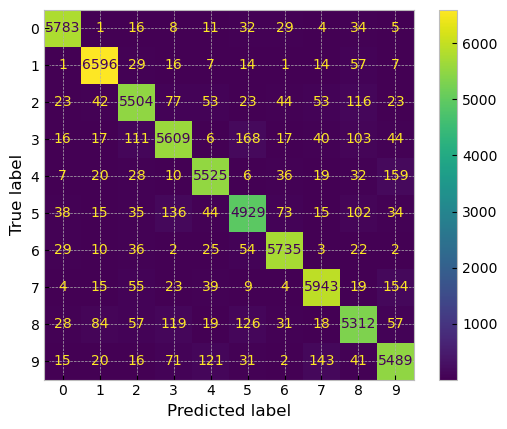

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(cm, display_labels=range(10));
disp.plot();

---

# Focusing on the Errors

Start by normalizing by the sample size per class:

In [33]:
row_sums = cm.sum(axis=1, keepdims=True)

norm_conf_mx = cm / row_sums

Next, fill the diagonal with zeros:

In [34]:
np.fill_diagonal(norm_conf_mx, 0)

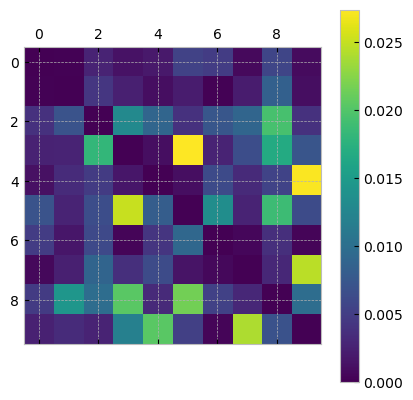

In [35]:
plt.matshow(norm_conf_mx)
plt.colorbar();

In [36]:
# Utility function
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = plt.cm.binary, **options)
    plt.axis('off')

In [37]:
cl_a, cl_b = 1, 7

X_aa = X_train[(t_train == cl_a) & (y_train == cl_a)] # TP
X_ab = X_train[(t_train == cl_a) & (y_train == cl_b)] # FN
X_ba = X_train[(t_train == cl_b) & (y_train == cl_a)] # FP
X_bb = X_train[(t_train == cl_b) & (y_train == cl_b)] # TN

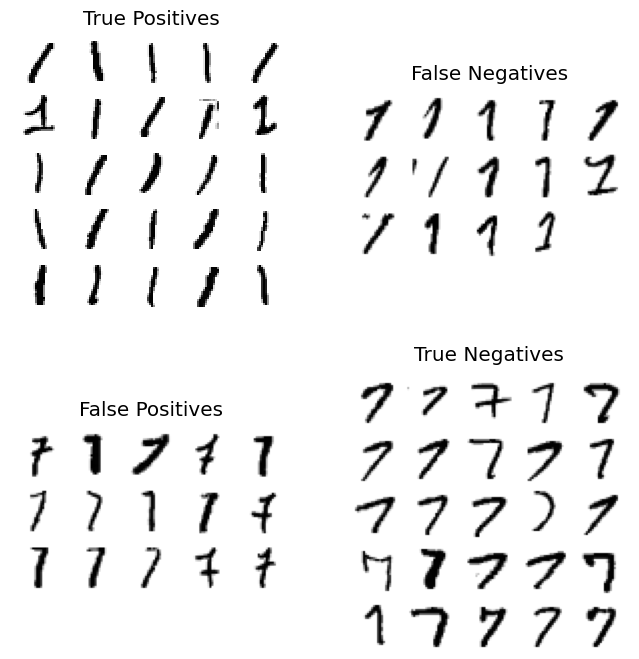

In [38]:
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5); plt.title('True Positives')
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5); plt.title('False Negatives')
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5); plt.title('False Positives')
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5); plt.title('True Negatives');

---

# Project 1

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

songs = pd.read_csv('datasets\Spotify_Song_Attributes.csv')

songs.head(5)

,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0


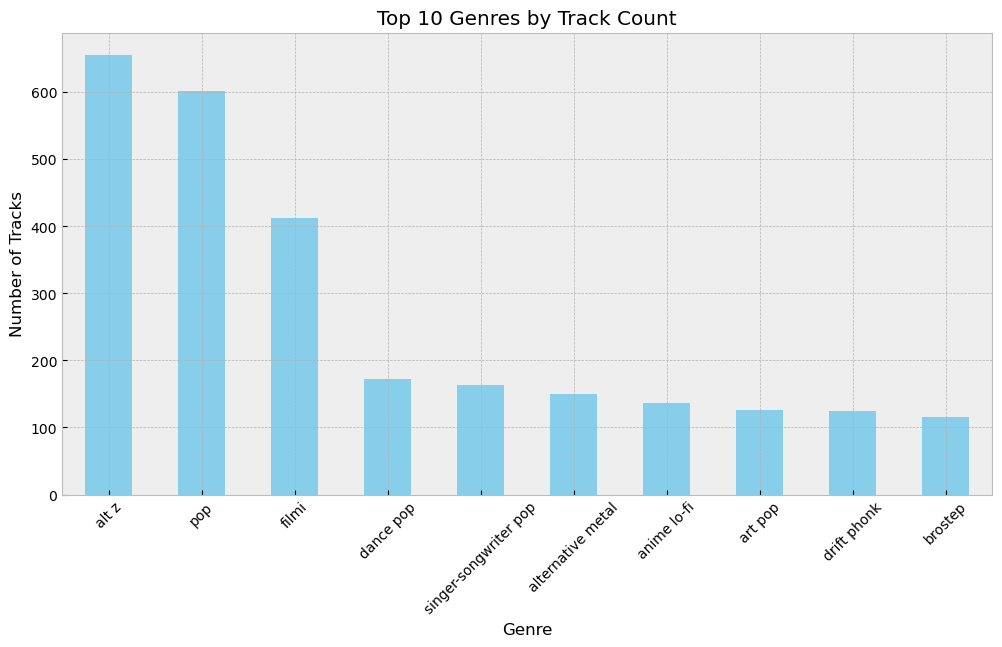

In [44]:
# Top Genres by Track Count
if 'genre' in songs.columns:
    plt.figure(figsize=(12, 6))
    songs['genre'].value_counts().nlargest(10).plot(kind='bar', color='skyblue')
    plt.xlabel("Genre")
    plt.ylabel("Number of Tracks")
    plt.title("Top 10 Genres by Track Count")
    plt.xticks(rotation=45)
    plt.show()

C:\Users\aramirezsalgado\AppData\Local\Temp\ipykernel_31932\3551642860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.index, y=top_artists.values, palette="viridis")


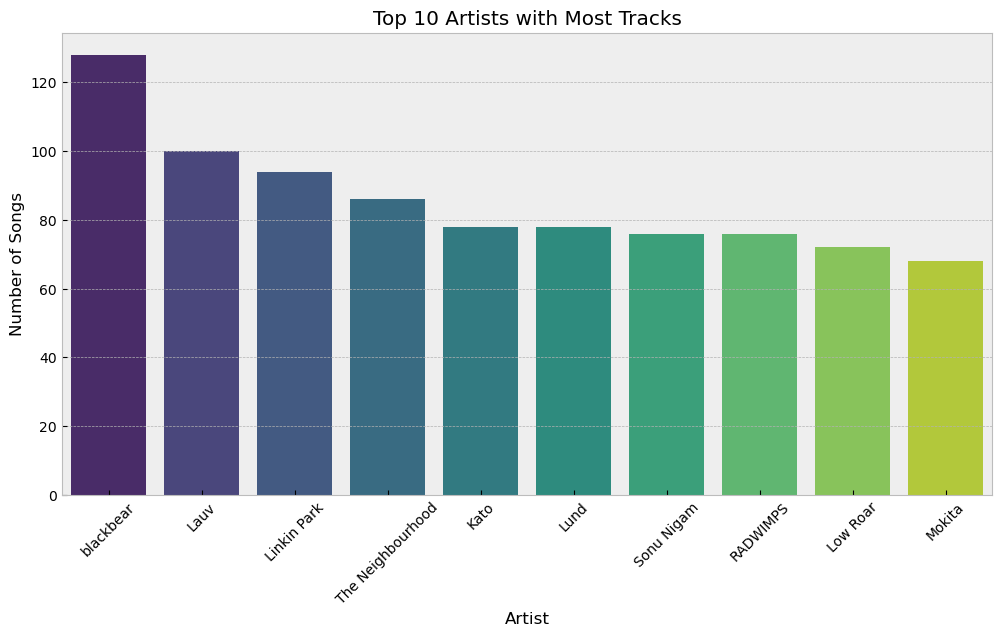

In [45]:
#  Top Artists by Track Count
plt.figure(figsize=(12, 6))
top_artists = songs['artistName'].value_counts().nlargest(10)
sns.barplot(x=top_artists.index, y=top_artists.values, palette="viridis")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.title("Top 10 Artists with Most Tracks")
plt.xticks(rotation=45)
plt.show()

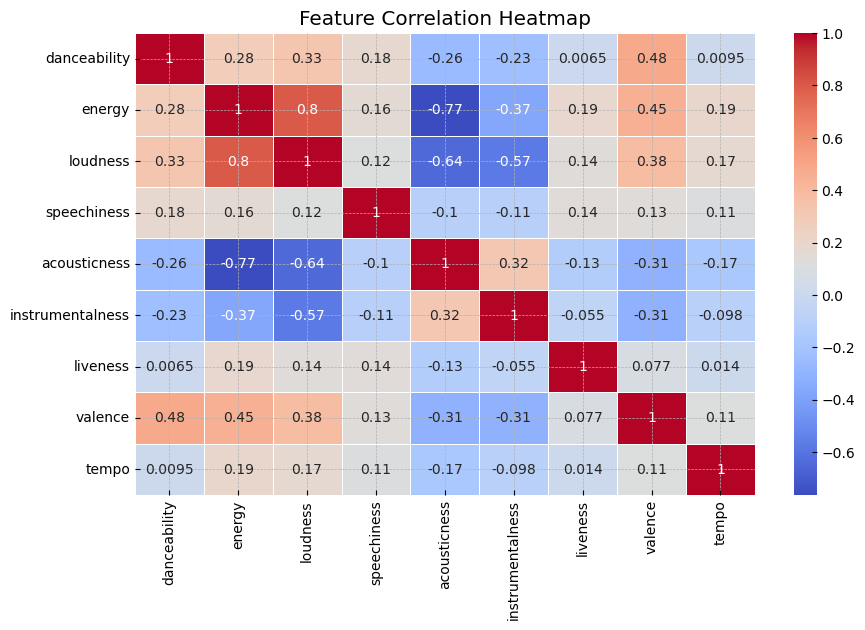

In [46]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = songs[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
